In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive mounted!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted!


In [ ]:
import os

# Your files are in root of My Drive
DRIVE = '/content/drive/MyDrive'

# Create destination folder
!mkdir -p "{DRIVE}/DualityHackathon/dataset"
!mkdir -p "{DRIVE}/DualityHackathon/scripts"

print("📦 Unzipping Scripts...")
!unzip -q "{DRIVE}/Offroad_Segmentation_Scripts.zip" \
       -d "{DRIVE}/DualityHackathon/scripts/"

print("📦 Unzipping Test Images...")
!unzip -q "{DRIVE}/Offroad_Segmentation_testImages.zip" \
       -d "{DRIVE}/DualityHackathon/dataset/"

print("📦 Unzipping Training Dataset (this will take 5-10 mins)...")
!unzip -q "{DRIVE}/Offroad_Segmentation_Training_Dataset.zip" \
       -d "{DRIVE}/DualityHackathon/dataset/"

print("✅ ALL DONE!")

📦 Unzipping Scripts...
📦 Unzipping Test Images...
📦 Unzipping Training Dataset (this will take 5-10 mins)...
✅ ALL DONE!


In [ ]:
# See folder structure
print("=== DATASET STRUCTURE ===")
for root, dirs, files in os.walk(f'{DRIVE}/DualityHackathon/dataset'):
    level = root.replace(f'{DRIVE}/DualityHackathon/dataset', '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}📁 {os.path.basename(root)}/')
    if level < 2:  # only show files 2 levels deep
        for f in files[:3]:  # show first 3 files only
            print(f'{indent}  📄 {f}')
        if len(files) > 3:
            print(f'{indent}  ... and {len(files)-3} more files')

print("\n=== SCRIPTS ===")
for root, dirs, files in os.walk(f'{DRIVE}/DualityHackathon/scripts'):
    for f in files:
        print(f'  📄 {f}')

=== DATASET STRUCTURE ===
📁 dataset/
  📁 Offroad_Segmentation_testImages/
    📁 Color_Images/
    📁 Segmentation/
  📁 Offroad_Segmentation_Training_Dataset/
    📁 train/
      📁 Color_Images/
      📁 Segmentation/
    📁 val/
      📁 Color_Images/
      📁 Segmentation/

=== SCRIPTS ===
  📄 train_segmentation.py
  📄 visualize.py
  📄 test_segmentation.py
  📄 create_env.bat
  📄 install_packages.bat
  📄 setup_env.bat


In [ ]:
# Let's see what Duality gave us
script_dir = f'{DRIVE}/DualityHackathon/scripts'

# Find train.py wherever it is
for root, dirs, files in os.walk(script_dir):
    for f in files:
        if 'train' in f.lower() and f.endswith('.py'):
            train_path = os.path.join(root, f)
            print(f"Found: {train_path}")
            print("="*50)
            with open(train_path, 'r') as file:
                print(file.read())

Found: /content/drive/MyDrive/DualityHackathon/scripts/train_segmentation.py
"""
Segmentation Training Script
Converted from train_mask.ipynb
Trains a segmentation head on top of DINOv2 backbone
"""

import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torch.optim as optim
import torchvision.transforms as transforms
from PIL import Image
import cv2
import os
import torchvision
from tqdm import tqdm

# Set matplotlib to non-interactive backend
plt.switch_backend('Agg')


# ============================================================================
# Utility Functions
# ============================================================================

def save_image(img, filename):
    """Save an image tensor to file after denormalizing."""
    img = np.array(img)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = np.moveaxis(img,

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# DINOv2 needs this
!pip install torch torchvision tqdm --quiet
!pip install opencv-python-headless --quiet

import torch
print(f"✅ GPU Available: {torch.cuda.is_available()}")
print(f"✅ Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ GPU Available: True
✅ Device: Tesla T4


In [ ]:
import os

DRIVE = '/content/drive/MyDrive'
BASE  = f'{DRIVE}/DualityHackathon'

# Dataset paths (matching your actual unzipped structure)
TRAIN_DIR = f'{BASE}/dataset/Offroad_Segmentation_Training_Dataset/train'
VAL_DIR   = f'{BASE}/dataset/Offroad_Segmentation_Training_Dataset/val'
TEST_DIR  = f'{BASE}/dataset/Offroad_Segmentation_testImages'
RUNS_DIR  = f'{BASE}/runs'

os.makedirs(RUNS_DIR, exist_ok=True)

# Verify everything exists
paths = {
    'Train RGB' : f'{TRAIN_DIR}/Color_Images',
    'Train Mask': f'{TRAIN_DIR}/Segmentation',
    'Val RGB'   : f'{VAL_DIR}/Color_Images',
    'Val Mask'  : f'{VAL_DIR}/Segmentation',
    'Test Images': f'{TEST_DIR}/Color_Images',
}

for name, path in paths.items():
    status = "✅" if os.path.exists(path) else "❌ MISSING"
    count  = len(os.listdir(path)) if os.path.exists(path) else 0
    print(f"{status} {name}: {count} files — {path}")

✅ Train RGB: 2857 files — /content/drive/MyDrive/DualityHackathon/dataset/Offroad_Segmentation_Training_Dataset/train/Color_Images
✅ Train Mask: 2857 files — /content/drive/MyDrive/DualityHackathon/dataset/Offroad_Segmentation_Training_Dataset/train/Segmentation
✅ Val RGB: 317 files — /content/drive/MyDrive/DualityHackathon/dataset/Offroad_Segmentation_Training_Dataset/val/Color_Images
✅ Val Mask: 317 files — /content/drive/MyDrive/DualityHackathon/dataset/Offroad_Segmentation_Training_Dataset/val/Segmentation
✅ Test Images: 1002 files — /content/drive/MyDrive/DualityHackathon/dataset/Offroad_Segmentation_testImages/Color_Images


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm

# ── Configuration ────────────────────────────────────
device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 2       # keep 2 for Colab RAM safety
N_EPOCHS   = 25      # more than their default 10
LR         = 1e-4
IMG_W      = int(((960/2) // 14) * 14)   # must be divisible by 14 for DINOv2
IMG_H      = int(((540/2) // 14) * 14)

print(f"Device    : {device}")
print(f"Image size: {IMG_W} x {IMG_H}")
print(f"Epochs    : {N_EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")

Device    : cuda
Image size: 476 x 266
Epochs    : 25
Batch size: 2


In [ ]:
# ── FIXED value_map — Duality's version was missing class 600 (Flowers)! ──
value_map = {
    0    : 0,   # Background
    100  : 1,   # Trees
    200  : 2,   # Lush Bushes
    300  : 3,   # Dry Grass
    500  : 4,   # Dry Bushes
    550  : 5,   # Ground Clutter
    600  : 6,   # Flowers  ← WAS MISSING IN ORIGINAL!
    700  : 7,   # Logs
    800  : 8,   # Rocks
    7100 : 9,   # Landscape
    10000: 10   # Sky
}
N_CLASSES = len(value_map)   # 11 classes now
print(f"✅ Total classes: {N_CLASSES}")

CLASS_NAMES = [
    'Background', 'Trees', 'Lush Bushes', 'Dry Grass',
    'Dry Bushes', 'Ground Clutter', 'Flowers',
    'Logs', 'Rocks', 'Landscape', 'Sky'
]

def convert_mask(mask):
    arr     = np.array(mask)
    new_arr = np.zeros_like(arr, dtype=np.uint8)
    for raw_val, new_val in value_map.items():
        new_arr[arr == raw_val] = new_val
    return Image.fromarray(new_arr)

✅ Total classes: 11


In [ ]:
class MaskDataset(Dataset):
    def __init__(self, data_dir, transform=None, mask_transform=None):
        self.image_dir      = os.path.join(data_dir, 'Color_Images')
        self.masks_dir      = os.path.join(data_dir, 'Segmentation')
        self.transform      = transform
        self.mask_transform = mask_transform
        self.data_ids       = sorted(os.listdir(self.image_dir))

    def __len__(self):
        return len(self.data_ids)

    def __getitem__(self, idx):
        fname    = self.data_ids[idx]
        image    = Image.open(os.path.join(self.image_dir, fname)).convert("RGB")
        mask     = Image.open(os.path.join(self.masks_dir, fname))
        mask     = convert_mask(mask)

        if self.transform:
            image = self.transform(image)
            mask  = self.mask_transform(mask) * 255

        return image, mask

# ── Transforms ────────────────────────────────────────
transform = transforms.Compose([
    transforms.Resize((IMG_H, IMG_W)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
mask_transform = transforms.Compose([
    transforms.Resize((IMG_H, IMG_W)),
    transforms.ToTensor(),
])

# ── DataLoaders ───────────────────────────────────────
train_ds = MaskDataset(TRAIN_DIR, transform, mask_transform)
val_ds   = MaskDataset(VAL_DIR,   transform, mask_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ Train samples: {len(train_ds)}")
print(f"✅ Val samples  : {len(val_ds)}")

✅ Train samples: 2857
✅ Val samples  : 317


In [ ]:
# This downloads DINOv2 from Facebook (~90MB, takes 1-2 mins)
print("⏳ Loading DINOv2 backbone (downloading if first time)...")

backbone = torch.hub.load(
    repo_or_dir="facebookresearch/dinov2",
    model="dinov2_vits14"   # small = fastest, good accuracy
)
backbone.eval()             # FROZEN — we never train this
backbone.to(device)

print("✅ DINOv2 loaded!")

# Get embedding size
with torch.no_grad():
    sample_imgs, _ = next(iter(train_loader))
    feats = backbone.forward_features(
                sample_imgs.to(device))["x_norm_patchtokens"]

N_EMBED = feats.shape[2]
print(f"✅ Embedding dim : {N_EMBED}")
print(f"✅ Patch tokens  : {feats.shape}")

⏳ Loading DINOv2 backbone (downloading if first time)...
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 197MB/s]


✅ DINOv2 loaded!
✅ Embedding dim : 384
✅ Patch tokens  : torch.Size([2, 646, 384])


In [ ]:
class SegmentationHead(nn.Module):
    def __init__(self, in_channels, out_channels, tokenW, tokenH):
        super().__init__()
        self.H, self.W = tokenH, tokenW

        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 128, kernel_size=7, padding=3),
            nn.GELU()
        )
        self.block = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=7, padding=3, groups=128),
            nn.GELU(),
            nn.Conv2d(128, 128, kernel_size=1),
            nn.GELU(),
        )
        self.classifier = nn.Conv2d(128, out_channels, 1)

    def forward(self, x):
        B, N, C = x.shape
        x = x.reshape(B, self.H, self.W, C).permute(0, 3, 1, 2)
        x = self.stem(x)
        x = self.block(x)
        return self.classifier(x)

seg_head = SegmentationHead(
    in_channels=N_EMBED,
    out_channels=N_CLASSES,
    tokenW=IMG_W // 14,
    tokenH=IMG_H // 14
).to(device)

print(f"✅ Segmentation head ready!")
print(f"   Params: {sum(p.numel() for p in seg_head.parameters()):,}")

✅ Segmentation head ready!
   Params: 2,432,907


In [ ]:
# Give more weight to rare classes (Flowers, Logs, Ground Clutter)
class_weights = torch.tensor([
    0.5,   # 0: Background
    1.0,   # 1: Trees
    1.5,   # 2: Lush Bushes
    2.0,   # 3: Dry Grass
    2.0,   # 4: Dry Bushes
    3.0,   # 5: Ground Clutter
    5.0,   # 6: Flowers      ← very rare
    5.0,   # 7: Logs         ← very rare
    2.0,   # 8: Rocks
    0.5,   # 9: Landscape    ← dominant
    0.5,   # 10: Sky         ← easy
]).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

# AdamW > SGD for convergence speed
optimizer = optim.AdamW(seg_head.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)

print("✅ Loss, optimizer, scheduler ready!")

✅ Loss, optimizer, scheduler ready!


In [ ]:
def compute_iou(pred_logits, target, num_classes=N_CLASSES):
    pred   = torch.argmax(pred_logits, dim=1).view(-1)
    target = target.view(-1)
    ious   = []
    for c in range(num_classes):
        inter = ((pred == c) & (target == c)).sum().float()
        union = ((pred == c) | (target == c)).sum().float()
        ious.append(float('nan') if union == 0 else (inter/union).item())
    return np.nanmean(ious)

def compute_pixel_acc(pred_logits, target):
    pred = torch.argmax(pred_logits, dim=1)
    return (pred == target).float().mean().item()

In [ ]:
history = {k: [] for k in [
    'train_loss','val_loss','train_iou','val_iou','train_acc','val_acc'
]}
best_iou = 0.0

print("🚀 Starting Training...\n")

for epoch in range(N_EPOCHS):
    # ── TRAIN ─────────────────────────────────────────
    seg_head.train()
    t_losses = []

    for imgs, masks in tqdm(train_loader, desc=f"Ep {epoch+1}/{N_EPOCHS} Train"):
        imgs, masks = imgs.to(device), masks.to(device)
        labels = masks.squeeze(1).long()

        with torch.no_grad():
            feats = backbone.forward_features(imgs)["x_norm_patchtokens"]

        logits  = seg_head(feats)
        outputs = F.interpolate(logits, size=imgs.shape[2:],
                                mode="bilinear", align_corners=False)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        t_losses.append(loss.item())

    # ── VALIDATE ──────────────────────────────────────
    seg_head.eval()
    v_losses, v_ious, v_accs = [], [], []
    t_ious, t_accs           = [], []

    with torch.no_grad():
        for imgs, masks in tqdm(val_loader, desc=f"Ep {epoch+1}/{N_EPOCHS} Val  "):
            imgs, masks = imgs.to(device), masks.to(device)
            labels = masks.squeeze(1).long()
            feats  = backbone.forward_features(imgs)["x_norm_patchtokens"]
            logits = seg_head(feats)
            outputs = F.interpolate(logits, size=imgs.shape[2:],
                                    mode="bilinear", align_corners=False)
            v_losses.append(criterion(outputs, labels).item())
            v_ious.append(compute_iou(outputs, labels))
            v_accs.append(compute_pixel_acc(outputs, labels))

    scheduler.step()

    # ── Record ────────────────────────────────────────
    tl = np.mean(t_losses)
    vl = np.mean(v_losses)
    vi = np.mean(v_ious)
    va = np.mean(v_accs)

    history['train_loss'].append(tl)
    history['val_loss'].append(vl)
    history['val_iou'].append(vi)
    history['val_acc'].append(va)

    print(f"\nEpoch {epoch+1:02d} | "
          f"Train Loss: {tl:.4f} | "
          f"Val Loss: {vl:.4f} | "
          f"Val IoU: {vi:.4f} | "
          f"Val Acc: {va:.4f}")

    # ── Save best model to Drive ──────────────────────
    if vi > best_iou:
        best_iou = vi
        torch.save({
            'epoch'     : epoch,
            'model_state': seg_head.state_dict(),
            'optimizer' : optimizer.state_dict(),
            'best_iou'  : best_iou,
        }, f'{RUNS_DIR}/best_model.pth')
        print(f"   💾 Best model saved! IoU = {best_iou:.4f}")

print(f"\n🏆 Training Done! Best Val IoU: {best_iou:.4f}")

🚀 Starting Training...



Ep 1/25 Val  : 100%|██████████| 159/159 [00:15<00:00, 10.34it/s]



Epoch 01 | Train Loss: 1.3373 | Val Loss: 1.2571 | Val IoU: 0.2755 | Val Acc: 0.6485
   💾 Best model saved! IoU = 0.2755


Ep 2/25 Val  : 100%|██████████| 159/159 [00:15<00:00, 10.34it/s]



Epoch 02 | Train Loss: 1.2537 | Val Loss: 1.2319 | Val IoU: 0.2831 | Val Acc: 0.6532
   💾 Best model saved! IoU = 0.2831


...


Epoch 23 | Train Loss: 1.1538 | Val Loss: 1.1783 | Val IoU: 0.3118 | Val Acc: 0.6710


Ep 24/25 Val  : 100%|██████████| 159/159 [00:16<00:00,  9.67it/s]



Epoch 24 | Train Loss: 1.1526 | Val Loss: 1.1783 | Val IoU: 0.3122 | Val Acc: 0.6713


Ep 25/25 Val  : 100%|██████████| 159/159 [00:15<00:00, 10.55it/s]


Epoch 25 | Train Loss: 1.1536 | Val Loss: 1.1782 | Val IoU: 0.3119 | Val Acc: 0.6712

🏆 Training Done! Best Val IoU: 0.3129


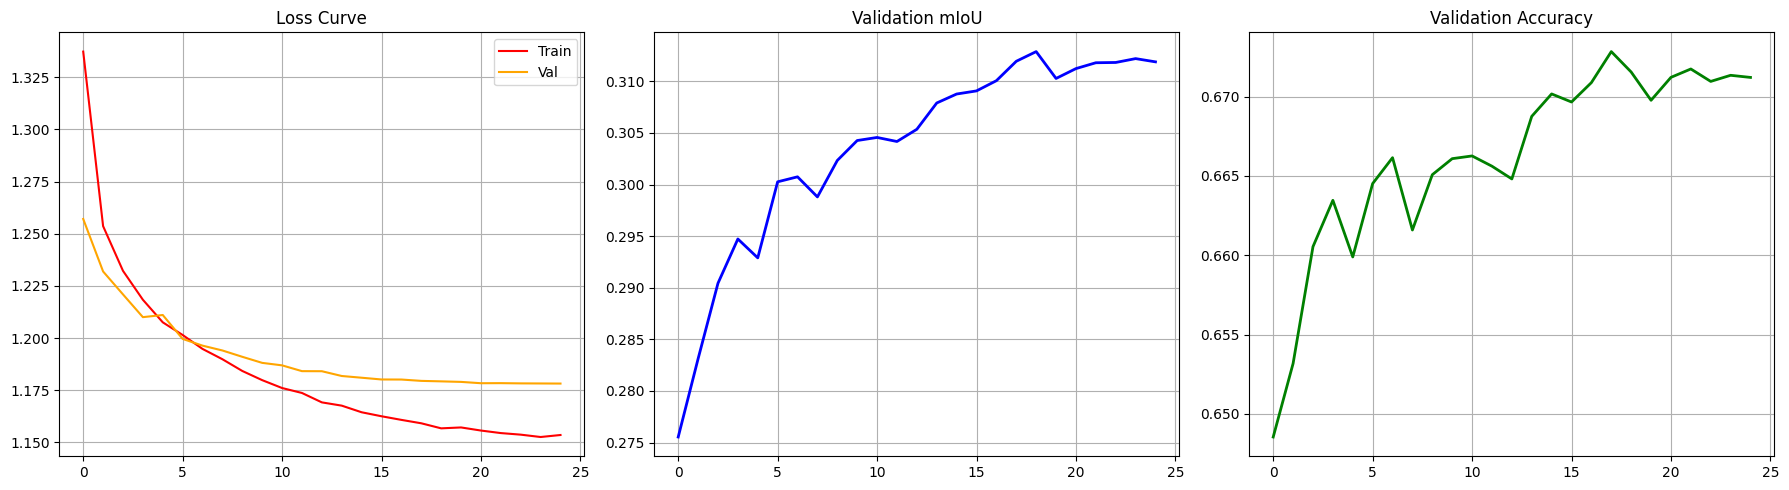

✅ Graphs saved to Drive!


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['train_loss'], label='Train', color='red')
axes[0].plot(history['val_loss'],   label='Val',   color='orange')
axes[0].set_title('Loss Curve');  axes[0].legend(); axes[0].grid(True)

axes[1].plot(history['val_iou'], color='blue', linewidth=2)
axes[1].set_title('Validation mIoU'); axes[1].grid(True)

axes[2].plot(history['val_acc'], color='green', linewidth=2)
axes[2].set_title('Validation Accuracy'); axes[2].grid(True)

plt.tight_layout()
plt.savefig(f'{RUNS_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Graphs saved to Drive!")

✅ Device: cuda
⏳ Loading DINOv2 backbone...


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


✅ Backbone loaded!
✅ Embedding dim: 384
✅ Model loaded! Best IoU was: 0.3129

🖼️  Testing on: ['cc0001086.png', 'mt0000141.png', 'ww10000358.png']


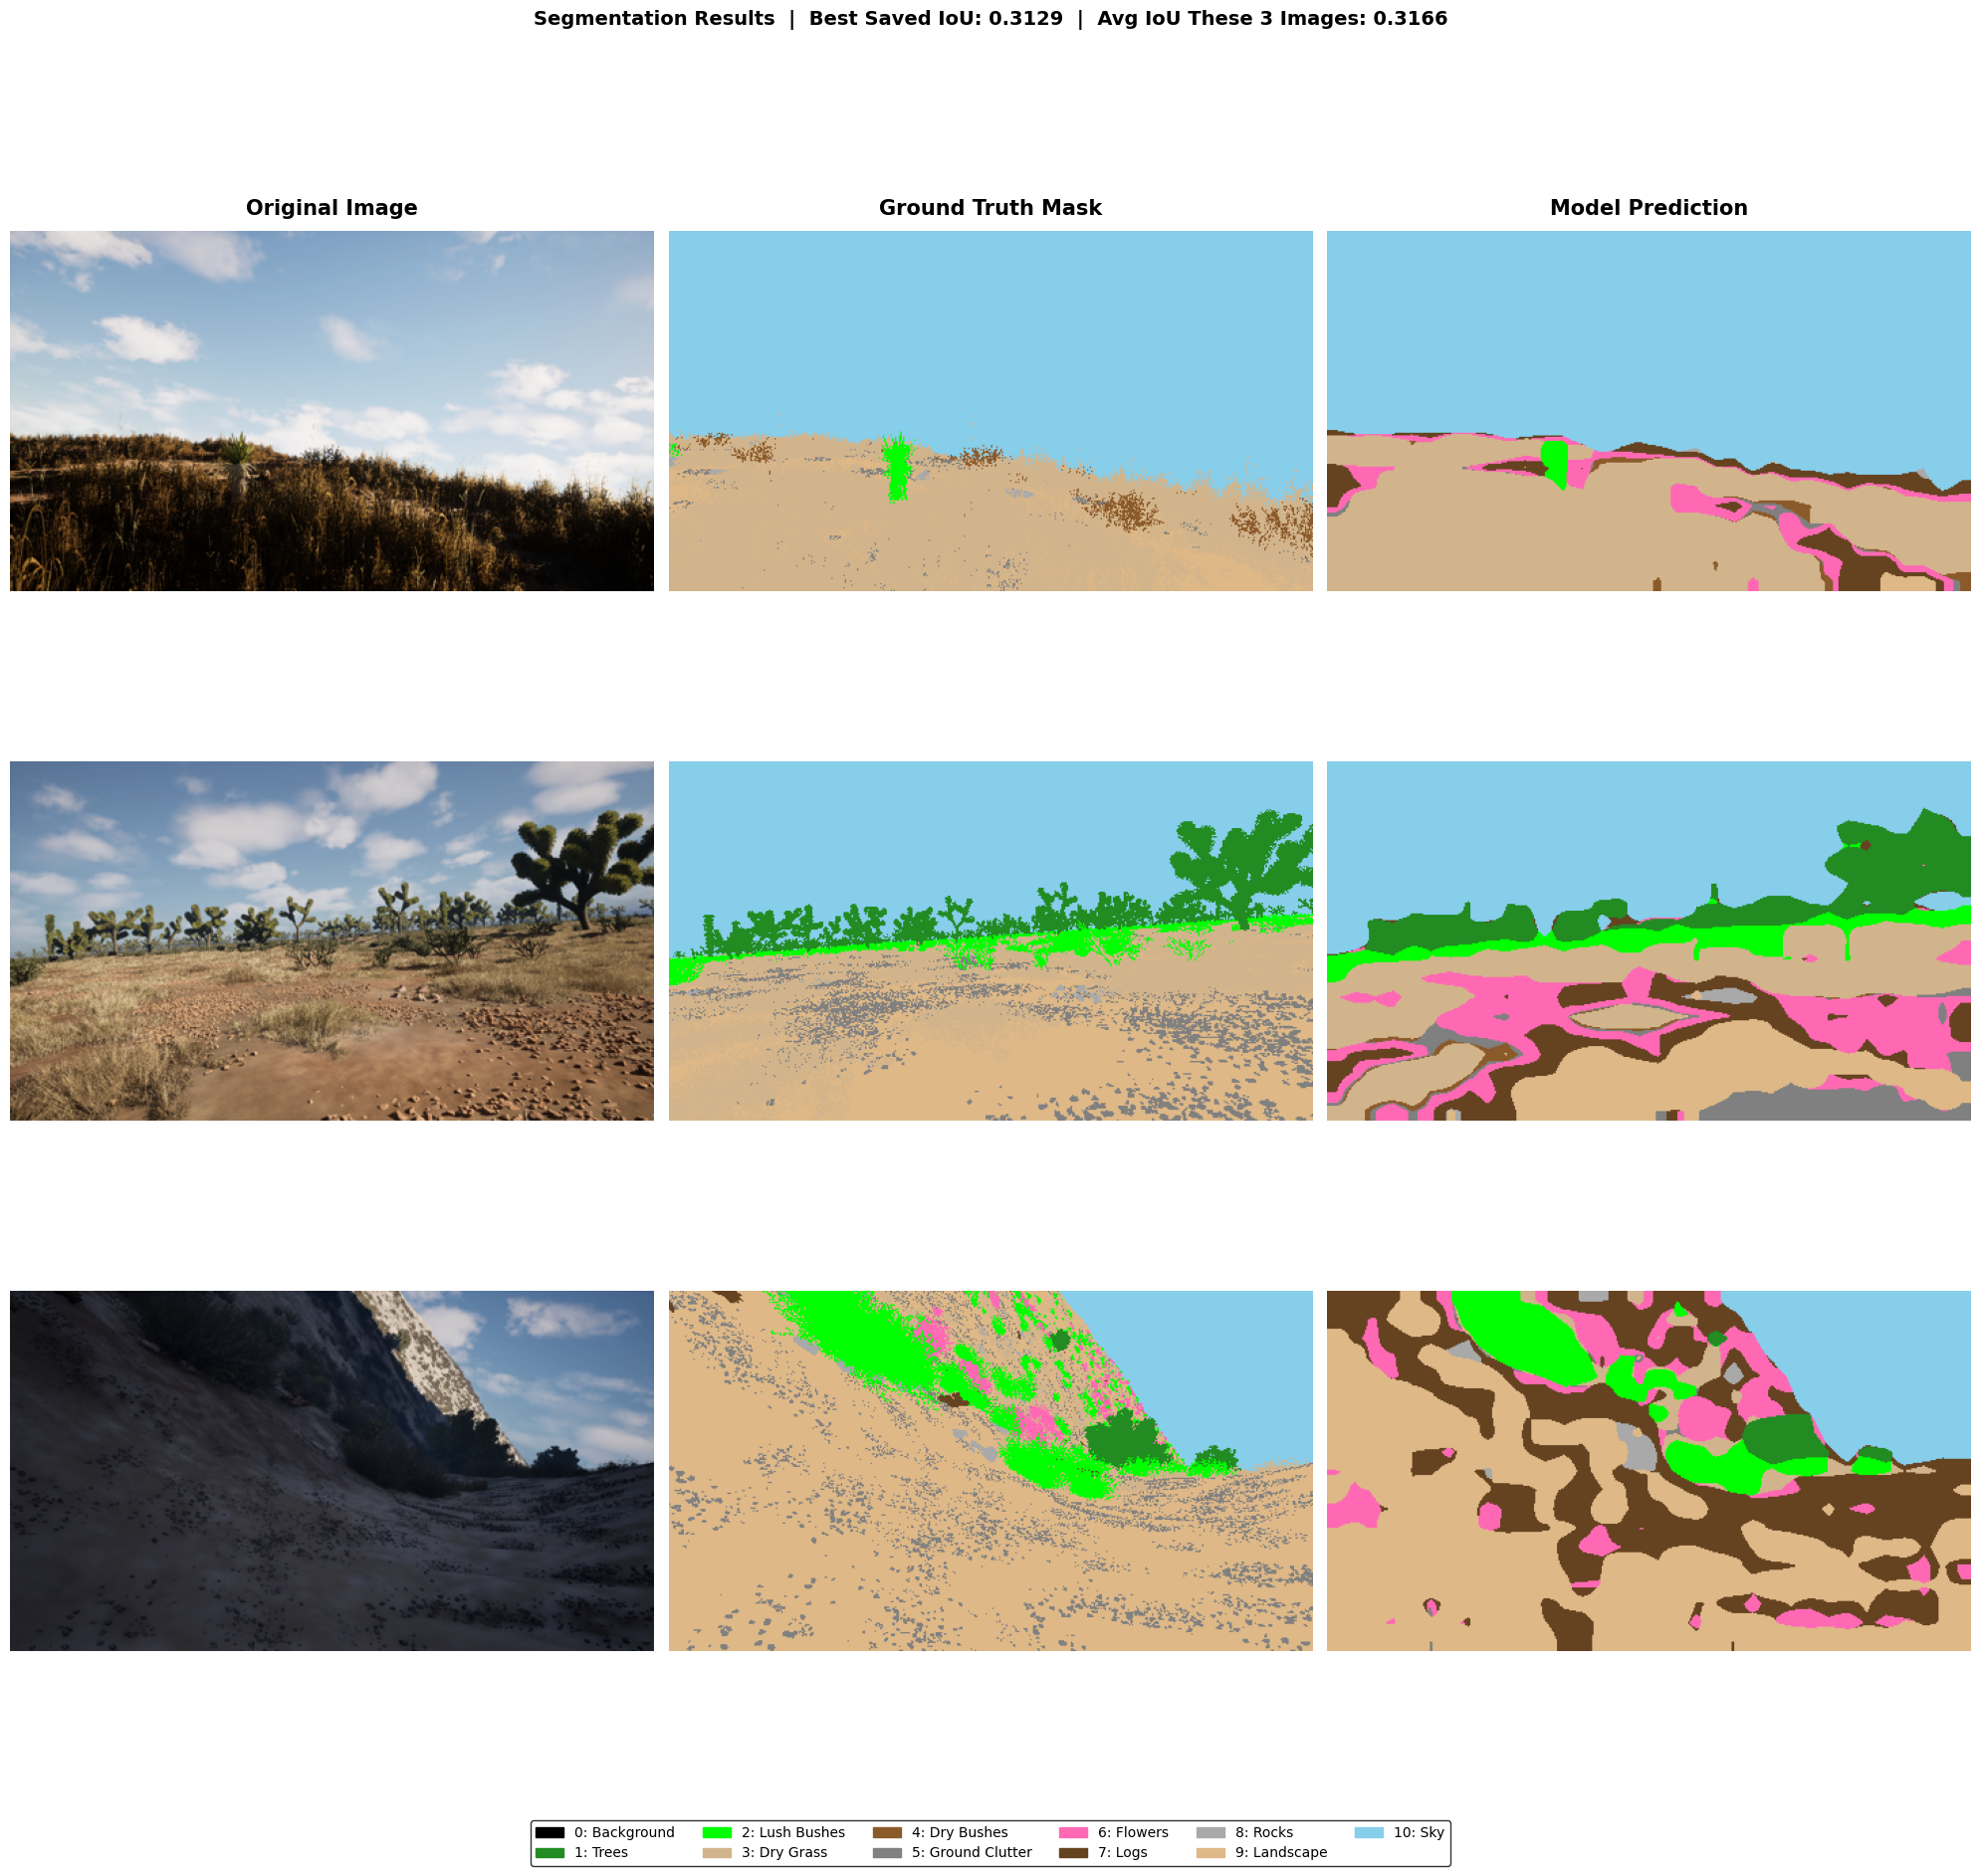


✅ Image saved to: /content/drive/MyDrive/DualityHackathon/runs/sample_predictions.png
📊 IoU per image:
   Image 1: cc0001086.png → IoU: 0.2827
   Image 2: mt0000141.png → IoU: 0.3313
   Image 3: ww10000358.png → IoU: 0.3359
📊 Average IoU: 0.3166


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn.functional as F
import numpy as np
from PIL import Image
import torchvision.transforms as transforms
import os, random

# ── Color map for visualization ───────────────────────────────
CLASS_COLORS = {
    0 : (0,   0,   0),    # Background   → Black
    1 : (34,  139, 34),   # Trees        → Forest Green
    2 : (0,   255, 0),    # Lush Bushes  → Bright Green
    3 : (210, 180, 140),  # Dry Grass    → Tan
    4 : (139, 90,  43),   # Dry Bushes   → Brown
    5 : (128, 128, 128),  # Gnd Clutter  → Gray
    6 : (255, 105, 180),  # Flowers      → Pink
    7 : (101, 67,  33),   # Logs         → Dark Brown
    8 : (169, 169, 169),  # Rocks        → Light Gray
    9 : (222, 184, 135),  # Landscape    → Burlywood
    10: (135, 206, 235),  # Sky          → Sky Blue
}

CLASS_NAMES = [
    'Background', 'Trees', 'Lush Bushes', 'Dry Grass',
    'Dry Bushes', 'Ground Clutter', 'Flowers',
    'Logs', 'Rocks', 'Landscape', 'Sky'
]

# ── value_map (same as training) ──────────────────────────────
value_map = {
    0    : 0,   # Background
    100  : 1,   # Trees
    200  : 2,   # Lush Bushes
    300  : 3,   # Dry Grass
    500  : 4,   # Dry Bushes
    550  : 5,   # Ground Clutter
    600  : 6,   # Flowers
    700  : 7,   # Logs
    800  : 8,   # Rocks
    7100 : 9,   # Landscape
    10000: 10   # Sky
}

def convert_mask(mask):
    """Convert raw pixel IDs → class indices 0-10"""
    arr     = np.array(mask)
    new_arr = np.zeros_like(arr, dtype=np.uint8)
    for raw_val, new_val in value_map.items():
        new_arr[arr == raw_val] = new_val
    return Image.fromarray(new_arr)

def mask_to_color(mask_2d):
    """Convert class index mask → RGB color image"""
    h, w  = mask_2d.shape
    color = np.zeros((h, w, 3), dtype=np.uint8)
    for cls_id, rgb in CLASS_COLORS.items():
        color[mask_2d == cls_id] = rgb
    return color

def compute_iou(pred_logits, target, num_classes=11):
    """Compute mean IoU"""
    pred   = torch.argmax(pred_logits, dim=1).view(-1)
    target = target.view(-1)
    ious   = []
    for c in range(num_classes):
        inter = ((pred == c) & (target == c)).sum().float()
        union = ((pred == c) | (target == c)).sum().float()
        if union == 0:
            ious.append(float('nan'))
        else:
            ious.append((inter / union).item())
    return np.nanmean(ious)

# ── Device setup ──────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device: {device}")

# ── Paths (same as training) ──────────────────────────────────
DRIVE    = '/content/drive/MyDrive'
BASE     = f'{DRIVE}/DualityHackathon'
VAL_DIR  = f'{BASE}/dataset/Offroad_Segmentation_Training_Dataset/val'
RUNS_DIR = f'{BASE}/runs'

# ── Image dimensions (same as training) ──────────────────────
IMG_W = int(((960 / 2) // 14) * 14)
IMG_H = int(((540 / 2) // 14) * 14)
N_CLASSES = 11

# ── Load DINOv2 backbone ──────────────────────────────────────
print("⏳ Loading DINOv2 backbone...")
backbone = torch.hub.load(
    repo_or_dir="facebookresearch/dinov2",
    model="dinov2_vits14"
)
backbone.eval()
backbone.to(device)
print("✅ Backbone loaded!")

# ── Rebuild segmentation head ─────────────────────────────────
import torch.nn as nn

class SegmentationHead(nn.Module):
    def __init__(self, in_channels, out_channels, tokenW, tokenH):
        super().__init__()
        self.H, self.W = tokenH, tokenW
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 128, kernel_size=7, padding=3),
            nn.GELU()
        )
        self.block = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=7, padding=3, groups=128),
            nn.GELU(),
            nn.Conv2d(128, 128, kernel_size=1),
            nn.GELU(),
        )
        self.classifier = nn.Conv2d(128, out_channels, 1)

    def forward(self, x):
        B, N, C = x.shape
        x = x.reshape(B, self.H, self.W, C).permute(0, 3, 1, 2)
        x = self.stem(x)
        x = self.block(x)
        return self.classifier(x)

# Get embedding dim from backbone
dummy = torch.zeros(1, 3, IMG_H, IMG_W).to(device)
with torch.no_grad():
    feats   = backbone.forward_features(dummy)["x_norm_patchtokens"]
N_EMBED = feats.shape[2]
print(f"✅ Embedding dim: {N_EMBED}")

seg_head = SegmentationHead(
    in_channels=N_EMBED,
    out_channels=N_CLASSES,
    tokenW=IMG_W // 14,
    tokenH=IMG_H // 14
).to(device)

# ── Load saved weights ────────────────────────────────────────
# ✅ FIX: weights_only=False for PyTorch 2.6
checkpoint = torch.load(
    f'{RUNS_DIR}/best_model.pth',
    map_location=device,
    weights_only=False      # ← THE FIX
)
seg_head.load_state_dict(checkpoint['model_state'])
seg_head.eval()
print(f"✅ Model loaded! Best IoU was: {checkpoint['best_iou']:.4f}")

# ── Transform ─────────────────────────────────────────────────
transform = transforms.Compose([
    transforms.Resize((IMG_H, IMG_W)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

# ── Pick 3 random validation images ───────────────────────────
val_img_dir  = f'{VAL_DIR}/Color_Images'
val_mask_dir = f'{VAL_DIR}/Segmentation'
all_files    = sorted(os.listdir(val_img_dir))
test_files   = random.sample(all_files, 3)   # ← change 3 to see more
print(f"\n🖼️  Testing on: {test_files}")

# ── Run inference & plot ──────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(20, 18))

col_titles = ['Original Image', 'Ground Truth Mask', 'Model Prediction']
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=15, fontweight='bold', pad=12)

iou_scores = []

for row, fname in enumerate(test_files):

    # ── Load original image ────────────────────────────────
    img_pil = Image.open(f'{val_img_dir}/{fname}').convert("RGB")
    img_t   = transform(img_pil).unsqueeze(0).to(device)

    # ── Load ground truth mask ─────────────────────────────
    gt_pil  = Image.open(f'{val_mask_dir}/{fname}')
    gt_mask = convert_mask(gt_pil)
    gt_arr  = np.array(gt_mask)

    # ── Run model prediction ───────────────────────────────
    with torch.no_grad():
        feats   = backbone.forward_features(img_t)["x_norm_patchtokens"]
        logits  = seg_head(feats)
        outputs = F.interpolate(
                    logits,
                    size=img_t.shape[2:],
                    mode="bilinear",
                    align_corners=False
                  )
        pred = outputs.argmax(dim=1).squeeze(0).cpu().numpy()

    # ── Resize GT to match prediction size ────────────────
    gt_resized = np.array(
        Image.fromarray(gt_arr).resize(
            (pred.shape[1], pred.shape[0]),
            Image.NEAREST
        )
    )

    # ── Compute per-image IoU ──────────────────────────────
    iou = compute_iou(
        outputs,
        torch.tensor(gt_resized).unsqueeze(0).to(device)
    )
    iou_scores.append(iou)

    # ── Col 0: Original image ──────────────────────────────
    display_img = img_pil.resize(
        (pred.shape[1], pred.shape[0])
    )
    axes[row][0].imshow(display_img)
    axes[row][0].set_ylabel(
        f'Image {row+1}\n{fname[:25]}',
        fontsize=9, labelpad=8
    )
    axes[row][0].axis('off')

    # ── Col 1: Ground truth colored mask ──────────────────
    axes[row][1].imshow(mask_to_color(gt_resized))
    axes[row][1].axis('off')

    # ── Col 2: Prediction colored mask + IoU ──────────────
    axes[row][2].imshow(mask_to_color(pred))
    axes[row][2].set_xlabel(
        f'IoU: {iou:.4f}',
        fontsize=13,
        color='white',
        bbox=dict(
            boxstyle='round,pad=0.4',
            facecolor='black',
            alpha=0.8
        )
    )
    axes[row][2].axis('off')

# ── Legend ────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(
        color=np.array(col)/255,
        label=f'{i}: {CLASS_NAMES[i]}'
    )
    for i, col in CLASS_COLORS.items()
]
fig.legend(
    handles=legend_patches,
    loc='lower center',
    ncol=6,
    fontsize=10,
    bbox_to_anchor=(0.5, -0.03),
    frameon=True,
    edgecolor='black'
)

# ── Title with overall average IoU ───────────────────────────
avg_iou = np.nanmean(iou_scores)
plt.suptitle(
    f'Segmentation Results  |  '
    f'Best Saved IoU: {checkpoint["best_iou"]:.4f}  |  '
    f'Avg IoU These 3 Images: {avg_iou:.4f}',
    fontsize=14,
    fontweight='bold',
    y=1.01
)

plt.tight_layout()

# ── Save to Drive ─────────────────────────────────────────────
save_path = f'{RUNS_DIR}/sample_predictions.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'='*50}")
print(f"✅ Image saved to: {save_path}")
print(f"📊 IoU per image:")
for i, (fname, iou) in enumerate(zip(test_files, iou_scores)):
    print(f"   Image {i+1}: {fname[:30]} → IoU: {iou:.4f}")
print(f"📊 Average IoU: {avg_iou:.4f}")
print(f"{'='*50}")

In [ ]:
import torch
import os
import json

# ── paths ──────────────────────────────────────────────────
DRIVE = '/content/drive/MyDrive'
SAVE_DIR = f'{DRIVE}/DualityHackathon/saved_model'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── 1. Save segmentation head weights ──────────────────────
head_path = os.path.join(SAVE_DIR, 'segmentation_head.pth')
torch.save(seg_head.state_dict(), head_path) # Changed 'classifier' to 'seg_head'
print(f"✅ Segmentation head saved → {head_path}")

# ── 2. Save model config so the web app can rebuild it ─────
config = {
    "backbone_size": "vits14",          # DINOv2 model used
    "n_classes": N_CLASSES,             # Using N_CLASSES (11) from notebook
    "image_w": IMG_W,                   # Using IMG_W from notebook
    "image_h": IMG_H,                   # Using IMG_H from notebook
    "n_embedding": N_EMBED,             # Using N_EMBED from notebook
    "class_names": CLASS_NAMES,         # Using CLASS_NAMES from notebook
    "class_colors": [
        [0,   0,   0],    # Background   → Black
        [34,  139, 34],   # Trees        → Forest Green
        [0,   255, 0],    # Lush Bushes  → Bright Green
        [210, 180, 140],  # Dry Grass    → Tan
        [139, 90,  43],   # Dry Bushes   → Brown
        [128, 128, 128],  # Gnd Clutter  → Gray
        [255, 105, 180],  # Flowers      → Pink
        [101, 67,  33],   # Logs         → Dark Brown
        [169, 169, 169],  # Rocks        → Light Gray
        [222, 184, 135],  # Landscape    → Burlywood
        [135, 206, 235]   # Sky          → Sky Blue
    ]
}
config_path = os.path.join(SAVE_DIR, 'model_config.json')
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)
print(f"✅ Config saved        → {config_path}")

print("\n📁 Files ready to download from Drive:")
print(f"   {head_path}")
print(f"   {config_path}")
print("\nDownload both files and place them next to app.py before running the web server.")

✅ Segmentation head saved → /content/drive/MyDrive/DualityHackathon/saved_model/segmentation_head.pth
✅ Config saved        → /content/drive/MyDrive/DualityHackathon/saved_model/model_config.json

📁 Files ready to download from Drive:
   /content/drive/MyDrive/DualityHackathon/saved_model/segmentation_head.pth
   /content/drive/MyDrive/DualityHackathon/saved_model/model_config.json

Download both files and place them next to app.py before running the web server.
